C:\Users\Jee Hye Kim\AppData\Local\Temp\ipykernel_26320\1672660774.py:21: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  vp = sns.violinplot(


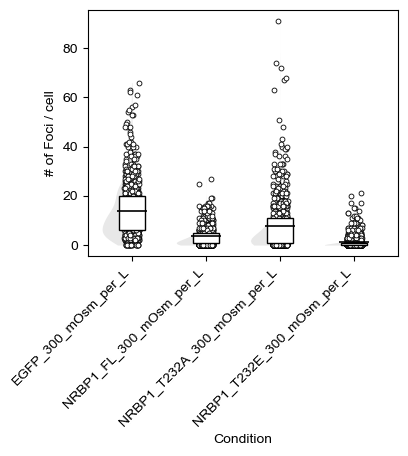

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load data
file_path = "Figure_4H_NRBP1_rescue_FL, T232A, T232E_Foci_Number.csv"
df = pd.read_csv(file_path)

# Reshape to long format
df_long = df.melt(var_name='Condition', value_name='Foci Count').dropna()

# Fixed color for all violins
violin_color = "#e8e8e8"
condition_order = df.columns.tolist()  # Ensure consistent order

plt.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(4, 3.2))

# Violin plot (full first)
vp = sns.violinplot(
    x='Condition', y='Foci Count', data=df_long,
    order=condition_order,
    inner=None, cut=0, scale='width', color=violin_color,
    linewidth=0, ax=ax
)

# Clip violins to left half only
for violin in ax.collections:
    path = violin.get_paths()[0]
    vertices = path.vertices
    center_x = np.median(vertices[:, 0])  # Find center x
    vertices[:, 0] = np.minimum(vertices[:, 0], center_x)  # Clip to left half
    path.vertices = vertices

# Boxplot (white fill)
sns.boxplot(
    x='Condition', y='Foci Count', data=df_long,
    order=condition_order, showcaps=False, showfliers=False, width=0.35,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'zorder': 4},
    medianprops={'color': 'black', 'linewidth': 1.2},
    whiskerprops={'color': 'black'}, capprops={'color': 'black'},
    ax=ax
)

# Stripplot (white dots with black edge)
sns.stripplot(
    x='Condition', y='Foci Count', data=df_long,
    order=condition_order, jitter=True, size=3.5, alpha=1,
    color='white', edgecolor='black', linewidth=0.6,
    ax=ax
)

# Mean as horizontal line
group_means = df_long.groupby('Condition')['Foci Count'].mean()
for i, cond in enumerate(condition_order):
    ax.hlines(
        y=group_means[cond], xmin=i - 0.2, xmax=i + 0.2,
        colors='black', linewidth=1.2, zorder=6
    )

# Remove legend (if any)
if ax.get_legend():
    ax.get_legend().remove()

# Labels
plt.xlabel("Condition")
plt.ylabel("# of Foci / cell")
plt.xticks(rotation=45, ha='right')

# Save
plt.savefig("Figure_4H_HalfViolin_Box_MeanLine.pdf", format="pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.show()


In [2]:
import pandas as pd
import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# --- Load data ---
file_path = "Figure_4H_NRBP1_rescue_FL, T232A, T232E_Foci_Number.csv"
df = pd.read_csv(file_path)

# --- Reshape to long format ---
df_long = df.melt(var_name="Condition", value_name="Foci_Count").dropna()
df_long["Genotype"] = df_long["Condition"].apply(lambda x: "EGFP" if "EGFP" in x else "NRBP1")
df_long["Expression"] = df_long["Condition"].apply(lambda x: "EGFP" if "EGFP" in x else ("NRBP1" if "FL" in x else ("NRBP1_T232A" if "T232A" in x else ("NRBP1_T232E"))))
df_long["Group"] = df_long["Expression"]

# --- Prepare groups ---
groups = df_long.groupby("Group")["Foci_Count"].apply(list)
pairs = list(combinations(groups.index, 2))

# --- Mann-Whitney U tests ---
results = []
for g1, g2 in pairs:
    u_stat, p_val = stats.mannwhitneyu(groups[g1], groups[g2], alternative='two-sided')
    results.append({"Group1": g1, "Group2": g2, "U_stat": u_stat, "p_uncorrected": p_val})

results_df = pd.DataFrame(results)

# --- FDR correction (Benjamini-Hochberg) ---
reject, p_corrected, _, _ = multipletests(results_df["p_uncorrected"], method='fdr_bh')
results_df["p_corrected_FDR"] = p_corrected
results_df["Significant"] = reject

# --- Sort by corrected p-value ---
results_df = results_df.sort_values("p_corrected_FDR")

# --- Save or display ---
print(results_df)

        Group1       Group2    U_stat  p_uncorrected  p_corrected_FDR  \
2         EGFP  NRBP1_T232E  803038.0  4.013321e-238    2.407993e-237   
0         EGFP        NRBP1  397661.0  5.335610e-107    1.600683e-106   
5  NRBP1_T232A  NRBP1_T232E  638914.0   2.659028e-91     5.318056e-91   
4        NRBP1  NRBP1_T232E  561645.0   5.740287e-58     8.610430e-58   
1         EGFP  NRBP1_T232A  357242.0   3.280834e-44     3.937001e-44   
3        NRBP1  NRBP1_T232A  181893.5   1.814404e-11     1.814404e-11   

   Significant  
2         True  
0         True  
5         True  
4         True  
1         True  
3         True  
